In [53]:
import cv2
from matplotlib import pyplot as plt

In [12]:
def rgb_to_lightness(color):
    color = color.tolist()
    r, g, b = color[0]/255, color[1]/255, color[2]/255

    l = 0.4122214708 * r + 0.5363325363 * g + 0.0514459929 * b
    m = 0.2119034982 * r + 0.6806995451 * g + 0.1073969566 * b
    s = 0.0883024619 * r + 0.2817188376 * g + 0.6299787005 * b

    l_ = pow(l, 1/3)
    m_ = pow(m, 1/3)
    s_ = pow(s, 1/3)

    return 0.2104542553*l_ + 0.7936177850*m_ - 0.0040720468*s_

In [39]:
img = cv2.imread('downscaled.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
lightness_map = [[]]

for i in range(img.shape[0]):
    lightness_map.append([])
    for j in range(img.shape[1]):
        lightness_map[i].append(rgb_to_lightness(img[i, j]))


In [41]:
def load_characters_and_brightness(char_file, brightness_file):
  """
  Loads characters and their corresponding brightness values from files.

  Args:
      char_file: Path to the file containing characters (one per line).
      brightness_file: Path to the file containing brightness values (one per line).

  Returns:
      A tuple containing a list of characters and a list of corresponding brightness values.
  """
  characters = []
  brightness_values = []
  with open(char_file, 'r', encoding='UTF-8') as f, open(brightness_file, 'r') as b:
    for char, brightness in zip(f, b):
      characters.append(char.strip())
      brightness_values.append(float(brightness.strip()))
  return characters, brightness_values

def brightness_to_char_index(brightness, brightness_values, min_brightness, max_brightness):
  """
  Finds the character index with the closest brightness value within the specified range.

  Args:
      brightness: The brightness value (between 0 and 1).
      brightness_values: A list of brightness values for each character.
      min_brightness: The minimum brightness value in your data (184.37421875 in your case).
      max_brightness: The maximum brightness value in your data (242.98734375 in your case).

  Returns:
      The index of the character in the list with the closest brightness value within the range.
  """
  # Normalize the brightness value to the range of the character brightness values.
  normalized_brightness = (brightness - 0) / (1 - 0) * (max_brightness - min_brightness) + min_brightness

  # Find the index of the character with the closest brightness value within the range.
  closest_index = min(range(len(brightness_values)), key=lambda i: abs(brightness_values[i] - normalized_brightness))
  return closest_index

def image_to_char_art(image_data, characters, brightness_values, min_brightness, max_brightness):
  """
  Converts a 2D list of brightness values (0-1) to a 2D list of characters using the brightness_to_char_index function.

  Args:
      image_data: A 2D list representing the downscaled image with brightness values (0-1).
      characters: A list of usable characters.
      brightness_values: A list of corresponding brightness values for each character.
      min_brightness: The minimum brightness value in your data (184.37421875 in your case).
      max_brightness: The maximum brightness value in your data (242.98734375 in your case).

  Returns:
      A 2D list containing the corresponding characters for each pixel in the image.
  """
  char_art = []
  for row in image_data:
    char_row = []
    for brightness in row:
      char_index = brightness_to_char_index(brightness, brightness_values, min_brightness, max_brightness)
      char_row.append(characters[char_index])
    char_art.append(char_row)
  return char_art

# Example usage (assuming your files are named characters.txt and character_density.txt)
characters, brightness_values = load_characters_and_brightness("characters.txt", "character_density.txt")

# Specify the minimum and maximum brightness values from your data
min_brightness = 184.37421875
max_brightness = 242.98734375

# Rest of the code remains the same (image data and usage examples)

result = image_to_char_art(lightness_map, characters, brightness_values, min_brightness, max_brightness)

179830


(array([3.0000e+00, 4.6000e+01, 5.3200e+02, 5.0360e+03, 2.2340e+04,
        4.6711e+04, 4.2383e+04, 3.1126e+04, 1.5691e+04, 1.5962e+04]),
 array([0.        , 0.1       , 0.2       , 0.3       , 0.4       ,
        0.5       , 0.6       , 0.7       , 0.79999999, 0.89999999,
        0.99999999]),
 <BarContainer object of 10 artists>)

findfont: Generic family 'sans-serif' not found because none of the following families were found: kaiu.ttf
findfont: Generic family 'sans-serif' not found because none of the following families were found: kaiu.ttf
findfont: Generic family 'sans-serif' not found because none of the following families were found: kaiu.ttf
findfont: Generic family 'sans-serif' not found because none of the following families were found: kaiu.ttf
findfont: Generic family 'sans-serif' not found because none of the following families were found: kaiu.ttf
findfont: Generic family 'sans-serif' not found because none of the following families were found: kaiu.ttf
findfont: Generic family 'sans-serif' not found because none of the following families were found: kaiu.ttf
findfont: Generic family 'sans-serif' not found because none of the following families were found: kaiu.ttf
findfont: Generic family 'sans-serif' not found because none of the following families were found: kaiu.ttf
findfont: Generic family 'sa

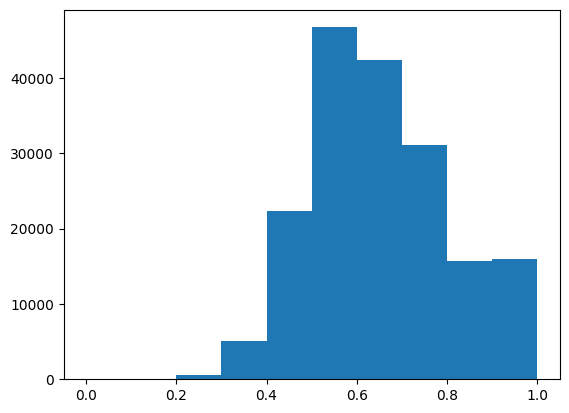

In [54]:
lightness_flat = []
for row in lightness_map:
    lightness_flat.extend(row)
print(len(lightness_flat))
plt.hist(lightness_flat)

In [55]:
def write_char_art_to_file(char_art, filename):
  """
  Writes the character art to a text file.

  Args:
      char_art: A 2D list containing the character art.
      filename: The name of the file to write the art to.
  """
  with open(filename, 'w', encoding='UTF-8') as f:
    for row in char_art:
      for char in row:
        f.write(char)
      f.write('\n')

write_char_art_to_file(result, "result.txt")


In [56]:
import json

with open("result_json.txt", 'w') as file:
  file.write(json.dumps(result))